# 04 — Comparison, Metrics, and Failure Analysis

**Goal:** Compare Baseline (Silero VAD + 500ms silence threshold) vs Smart (VAD + Whisper ASR + LLM)
across all 14 ground truth clips.

**What this notebook produces:**
1. Side-by-side per-clip results table
2. Aggregate metrics (Precision, Recall, False-cut rate)
3. Latency analysis (VAD vs ASR+LLM cost breakdown)
4. Failure analysis blueprint

In [18]:
import os
import json
import time
import numpy as np
import onnxruntime as ort
import librosa
import librosa.display
import matplotlib.pyplot as plt
import whisper
from openai import OpenAI
from collections import Counter

client = OpenAI(
    api_key="api_key",
    base_url="https://openrouter.ai/api/v1"
)

MODEL_PATH = '../models/silero_vad.onnx'
DATA_DIR   = '../data'

print('onnxruntime:', ort.__version__)
print('librosa    :', librosa.__version__)
print('Whisper    :', whisper.__version__)

onnxruntime: 1.25.1
librosa    : 0.11.0
Whisper    : 20250625


In [8]:
class SileroVAD:
    SAMPLE_RATE      = 16000
    CHUNK_SAMPLES    = 512   # 32ms at 16kHz
    CONTEXT_SAMPLES  = 64

    def __init__(self, model_path):
        self.session = ort.InferenceSession(model_path)

    def get_speech_probabilities(self, audio):
        state = np.zeros((2, 1, 128), dtype=np.float32)
        context = np.zeros(self.CONTEXT_SAMPLES, dtype=np.float32)
        sr = np.array(self.SAMPLE_RATE, dtype=np.int64)
        probs = []
        for start in range(0, len(audio), self.CHUNK_SAMPLES):
            chunk = audio[start:start + self.CHUNK_SAMPLES]
            if len(chunk) < self.CHUNK_SAMPLES:
                chunk = np.pad(chunk, (0, self.CHUNK_SAMPLES - len(chunk)))
            x = np.concatenate([context, chunk]).reshape(1, -1).astype(np.float32)
            prob, state = self.session.run(None, {'input': x, 'state': state, 'sr': sr})
            context = chunk[-self.CONTEXT_SAMPLES:].astype(np.float32)
            t = start / self.SAMPLE_RATE
            probs.append((t, float(prob[0][0])))
        return probs

vad = SileroVAD(MODEL_PATH)
model_asr = whisper.load_model("small", device="cpu")
print('SileroVAD and Whisper loaded.')

SileroVAD and Whisper loaded.


In [9]:
VAD_THRESHOLD = 0.5

def segments_from_mask(times, mask, chunk_duration):
    segments = []
    in_speech = False
    seg_start = None
    for t, s in zip(times, mask):
        if s and not in_speech:
            seg_start = t
            in_speech = True
        elif not s and in_speech:
            segments.append((seg_start, t))
            in_speech = False
    if in_speech:
        segments.append((seg_start, times[-1] + chunk_duration))
    return segments


def get_vad_segments(audio):
    """Run VAD and return speech segments + time taken."""
    t0 = time.time()
    probs = vad.get_speech_probabilities(audio)
    vad_time = time.time() - t0

    times = np.array([t for t, _ in probs])
    speech_probs = np.array([p for _, p in probs])
    mask = speech_probs > VAD_THRESHOLD
    chunk_dur = SileroVAD.CHUNK_SAMPLES / SileroVAD.SAMPLE_RATE
    segs = segments_from_mask(times, mask, chunk_dur)
    return segs, vad_time

In [10]:
def predict_done_baseline(speech_segments, total_duration, threshold_ms=500):
    """Baseline: first silence gap >= threshold = 'user done'."""
    threshold_s = threshold_ms / 1000.0
    if not speech_segments:
        return None
    for i in range(len(speech_segments) - 1):
        gap_start = speech_segments[i][1]
        gap_end   = speech_segments[i + 1][0]
        if gap_end - gap_start >= threshold_s:
            return gap_start
    trailing = total_duration - speech_segments[-1][1]
    if trailing >= threshold_s:
        return speech_segments[-1][1]
    return None

In [11]:
SYSTEM_PROMPT = """You are an endpoint detection system for a realtime voice assistant.

Classify the transcript into one of:
finished
unfinished
wait

Examples:

Transcript: "Book a flight to Mumbai"
Answer: finished

Transcript: "I want to book a flight to..."
Answer: unfinished

Transcript: "uh wait one second"
Answer: wait

Transcript: "Hold on, dont speak yet"
Answer: wait

Transcript: "Can you also"
Answer: unfinished

Transcript: "What's the weather in Delhi?"
Answer: finished

Now classify:"""


def parse_llm_label(raw_text):
    """Extract classification label from LLM response (robust parsing)."""
    raw = raw_text.strip().lower()
    for label in ("unfinished", "wait", "finished"):
        if label in raw:
            return label
    return "unfinished"


def get_prediction_from_llm(audio, gap_start):
    """Transcribe audio[0:gap_start] then classify with LLM. Returns (label, asr_time, llm_time)."""
    gap_start_in_indices = int(gap_start * SileroVAD.SAMPLE_RATE)
    audio_chunk = audio[:gap_start_in_indices]

    # ASR timing
    t0 = time.time()
    text_asr = model_asr.transcribe(audio_chunk, condition_on_previous_text=False, language="en")
    asr_time = time.time() - t0

    if not text_asr["text"].strip():
        return "unfinished", asr_time, 0.0

    transcript = text_asr["text"].strip()

    # LLM timing
    t0 = time.time()
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b:free",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f'Transcript: "{transcript}"\nAnswer:'},
        ],
        temperature=0,
        max_tokens=5,
    )
    llm_time = time.time() - t0

    raw = response.choices[0].message.content
    return parse_llm_label(raw), asr_time, llm_time


def predict_done_smart(audio, speech_segments, total_duration, threshold_ms=500):
    """Smart approach with latency tracking. Returns (timestamp, class, total_asr_ms, total_llm_ms, num_llm_calls)."""
    threshold_s = threshold_ms / 1000.0
    total_asr_ms = 0.0
    total_llm_ms = 0.0
    num_llm_calls = 0

    if not speech_segments:
        return None, "none", 0, 0, 0

    for i in range(len(speech_segments) - 1):
        gap_start = speech_segments[i][1]
        gap_end   = speech_segments[i + 1][0]
        if gap_end - gap_start >= threshold_s:
            label, asr_t, llm_t = get_prediction_from_llm(audio, gap_start)
            total_asr_ms += asr_t * 1000
            total_llm_ms += llm_t * 1000
            num_llm_calls += 1
            if label == "finished":
                return gap_start, label, total_asr_ms, total_llm_ms, num_llm_calls
            elif label == "wait":
                return gap_start, label, total_asr_ms, total_llm_ms, num_llm_calls

    trailing = total_duration - speech_segments[-1][1]
    if trailing >= threshold_s:
        label, asr_t, llm_t = get_prediction_from_llm(audio, speech_segments[-1][1])
        total_asr_ms += asr_t * 1000
        total_llm_ms += llm_t * 1000
        num_llm_calls += 1
        return speech_segments[-1][1], label, total_asr_ms, total_llm_ms, num_llm_calls

    return None, "none", total_asr_ms, total_llm_ms, num_llm_calls

## Run Baseline and Smart on all clips

In [12]:
labels_path = os.path.join(DATA_DIR, 'labels.json')
with open(labels_path) as f:
    labels = json.load(f)

BATCH_SIZE = 7
WAIT_SECONDS = 10

results = []

valid_files = [(fn, clip) for fn, clip in labels.items() if not fn.startswith('_') and os.path.exists(os.path.join(DATA_DIR, fn))]

total = len(valid_files)
for batch_start in range(0, total, BATCH_SIZE):
    batch_num = (batch_start // BATCH_SIZE) + 1
    batch = valid_files[batch_start: batch_start + BATCH_SIZE]
    print(f"\n{'='*70}")
    print(f"BATCH {batch_num}")
    print(f"{'='*70}")

    for filename, clip in batch:
        clip_path = os.path.join(DATA_DIR, filename)
        y_clip, _ = librosa.load(clip_path, sr=SileroVAD.SAMPLE_RATE)
        duration = len(y_clip) / SileroVAD.SAMPLE_RATE
        chunk_dur = SileroVAD.CHUNK_SAMPLES / SileroVAD.SAMPLE_RATE

        # --- VAD (shared) with timing ---
        segs, vad_ms = get_vad_segments(y_clip)
        vad_ms *= 1000  # convert to ms

        # --- Baseline ---
        baseline_pred = predict_done_baseline(segs, duration, threshold_ms=500)

        # --- Smart ---
        print(f"  Processing: {filename}")
        smart_pred, smart_class, asr_ms, llm_ms, n_llm = predict_done_smart(
            y_clip, segs, duration, threshold_ms=500
        )

        gt = clip.get('user_finished_at_s')
        gt_class = clip.get('overall_class', '?')

        # Baseline verdict
        if gt_class == 'wait':
            b_verdict = 'cut'  # baseline can't detect wait, always responds = cut
        elif baseline_pred is None:
            b_verdict = 'none'
        elif gt is None:
            b_verdict = '?'
        elif baseline_pred - gt < -0.3:
            b_verdict = 'cut'
        elif baseline_pred - gt > 0.5:
            b_verdict = 'late'
        else:
            b_verdict = 'ok'

        # Smart verdict
        if smart_class == 'wait' and gt_class == 'wait':
            s_verdict = 'ok'  # correctly identified wait
        elif smart_class == 'wait' and gt_class != 'wait':
            s_verdict = 'cut'  # false wait
        elif smart_pred is None:
            s_verdict = 'none'
        elif gt is None:
            s_verdict = '?'
        elif smart_class == 'unfinished':
            s_verdict = 'ok'  # correctly said not done at end of audio
        elif smart_pred - gt < -0.3:
            s_verdict = 'cut'
        elif smart_pred - gt > 0.5:
            s_verdict = 'late'
        else:
            s_verdict = 'ok'

        results.append({
            'clip': filename,
            'text': clip.get('text', '')[:50],
            'gt_class': gt_class,
            'gt': gt,
            'baseline_pred': baseline_pred,
            'baseline_verdict': b_verdict,
            'smart_pred': smart_pred,
            'smart_class': smart_class,
            'smart_verdict': s_verdict,
            'vad_ms': vad_ms,
            'asr_ms': asr_ms,
            'llm_ms': llm_ms,
            'n_llm_calls': n_llm,
        })

    print(f"\nBATCH {batch_num} COMPLETE")
    if batch_start + BATCH_SIZE < total:
        print(f"Waiting {WAIT_SECONDS}s before next batch...")
        time.sleep(WAIT_SECONDS)

print("\n\nAll clips processed.")


BATCH 1
  Processing: clip-01.wav
  Processing: clip-02.wav
  Processing: clip-03.wav
  Processing: clip-04.wav
  Processing: clip-05.wav
  Processing: clip-06.wav
  Processing: clip-07.wav

BATCH 1 COMPLETE
Waiting 10s before next batch...

BATCH 2
  Processing: clip-08.wav
  Processing: clip-09.wav
  Processing: clip-10.wav
  Processing: clip-11.wav
  Processing: clip-12.wav
  Processing: clip-13.wav
  Processing: clip-14.wav

BATCH 2 COMPLETE


All clips processed.


## Side-by-Side Per-Clip Results

In [13]:
print(f"{'Clip':<14} {'GT Class':<10} {'GT(s)':>6} | {'Base(s)':>7} {'B.Verd':<6} | {'Smart(s)':>8} {'S.Class':<10} {'S.Verd':<6} | {'Text'}")
print('-' * 120)
for r in results:
    gt_s   = f"{r['gt']:.2f}" if r['gt'] is not None else '--'
    bp     = f"{r['baseline_pred']:.2f}" if r['baseline_pred'] is not None else '--'
    sp     = f"{r['smart_pred']:.2f}" if r['smart_pred'] is not None else '--'
    print(
        f"{r['clip']:<14} {r['gt_class']:<10} {gt_s:>6} | "
        f"{bp:>7} {r['baseline_verdict']:<6} | "
        f"{sp:>8} {r['smart_class']:<10} {r['smart_verdict']:<6} | "
        f"{r['text']}"
    )

# Quick counts
print()
b_counts = Counter(r['baseline_verdict'] for r in results)
s_counts = Counter(r['smart_verdict'] for r in results)
print(f"Baseline verdicts: {dict(b_counts)}")
print(f"Smart verdicts:    {dict(s_counts)}")

Clip           GT Class    GT(s) | Base(s) B.Verd | Smart(s) S.Class    S.Verd | Text
------------------------------------------------------------------------------------------------------------------------
clip-01.wav    finished     5.80 |    5.70 ok     |     5.70 finished   ok     | I want to book a flight to Bangalore for next Tues
clip-02.wav    finished     5.90 |    5.70 ok     |     5.70 finished   ok     | I want to book a flight to ...um.. Bangalore for n
clip-03.wav    finished     4.90 |    4.80 ok     |     4.80 finished   ok     | Hmm I think ... I. aaa. want a window seat please.
clip-04.wav    finished     1.80 |    1.54 ok     |     1.54 finished   ok     | Yes.
clip-05.wav    finished     2.20 |    2.08 ok     |     2.08 finished   ok     | No, that's not right.
clip-06.wav    finished     3.80 |    3.68 ok     |     3.68 finished   ok     | What was the price for the morning flight you ment
clip-07.wav    finished     5.90 |    1.89 cut    |     1.89 finished   cut 

## Aggregate Metrics: Precision, Recall, False-Cut Rate

In [14]:
def compute_metrics(results, approach='baseline'):
    """
    Metrics:
    - Precision: of all 'user is done' predictions, how many were actually correct?
    - Recall: of all true 'user done' moments, how many did the system catch?
    - False-cut rate: how often did the system say 'done' while user was still speaking?
    """
    true_positives = 0  # correctly said 'done' (within 0.5s of GT, or correctly classified wait)
    false_positives = 0  # said 'done' but user was still speaking (cut)
    false_negatives = 0  # user was done but system didn't fire or said 'unfinished'
    total_predictions = 0
    total_actual_done = 0

    for r in results:
        gt_class = r['gt_class']
        if approach == 'baseline':
            verdict = r['baseline_verdict']
            pred = r['baseline_pred']
        else:
            verdict = r['smart_verdict']
            pred = r['smart_pred']

        if gt_class == 'finished':
            total_actual_done += 1

        if pred is not None and (approach == 'baseline' or r.get('smart_class') in ('finished',)):
            total_predictions += 1

        if verdict == 'ok' and gt_class == 'finished':
            true_positives += 1
        elif verdict == 'cut':
            false_positives += 1
        elif verdict in ('none', ) and gt_class == 'finished':
            false_negatives += 1

    precision = true_positives / total_predictions if total_predictions > 0 else 0
    recall = true_positives / total_actual_done if total_actual_done > 0 else 0
    false_cut_rate = false_positives / len(results) if len(results) > 0 else 0

    return {
        'precision': precision,
        'recall': recall,
        'false_cut_rate': false_cut_rate,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'total_predictions': total_predictions,
        'total_actual_done': total_actual_done,
    }

baseline_metrics = compute_metrics(results, 'baseline')
smart_metrics = compute_metrics(results, 'smart')

print(f"{'Metric':<25} {'Baseline':>10} {'Smart':>10}")
print('-' * 50)
print(f"{'Precision':<25} {baseline_metrics['precision']:>10.2%} {smart_metrics['precision']:>10.2%}")
print(f"{'Recall':<25} {baseline_metrics['recall']:>10.2%} {smart_metrics['recall']:>10.2%}")
print(f"{'False-cut rate':<25} {baseline_metrics['false_cut_rate']:>10.2%} {smart_metrics['false_cut_rate']:>10.2%}")
print()
print(f"{'True Positives':<25} {baseline_metrics['true_positives']:>10} {smart_metrics['true_positives']:>10}")
print(f"{'False Positives (cuts)':<25} {baseline_metrics['false_positives']:>10} {smart_metrics['false_positives']:>10}")
print(f"{'False Negatives':<25} {baseline_metrics['false_negatives']:>10} {smart_metrics['false_negatives']:>10}")

Metric                      Baseline      Smart
--------------------------------------------------
Precision                     64.29%     84.62%
Recall                        69.23%     84.62%
False-cut rate                35.71%     14.29%

True Positives                     9         11
False Positives (cuts)             5          2
False Negatives                    0          0


## Latency Analysis: VAD vs ASR vs LLM

In [15]:
print(f"{'Clip':<14} {'VAD(ms)':>8} {'ASR(ms)':>8} {'LLM(ms)':>8} {'Total(ms)':>10} {'#LLM':>5}")
print('-' * 60)
total_vad = total_asr = total_llm = 0
total_calls = 0
for r in results:
    v = r['vad_ms']
    a = r['asr_ms']
    l = r['llm_ms']
    total = v + a + l
    n = r['n_llm_calls']
    total_vad += v
    total_asr += a
    total_llm += l
    total_calls += n
    print(f"{r['clip']:<14} {v:>8.1f} {a:>8.1f} {l:>8.1f} {total:>10.1f} {n:>5}")

print('-' * 60)
n_clips = len(results)
print(f"{'AVERAGE':<14} {total_vad/n_clips:>8.1f} {total_asr/n_clips:>8.1f} {total_llm/n_clips:>8.1f} {(total_vad+total_asr+total_llm)/n_clips:>10.1f} {total_calls/n_clips:>5.1f}")
print()
print("--- Cost Breakdown ---")
if total_vad + total_asr + total_llm > 0:
    grand = total_vad + total_asr + total_llm
    print(f"  VAD:  {total_vad/grand:>6.1%}  ({total_vad:.0f}ms total)")
    print(f"  ASR:  {total_asr/grand:>6.1%}  ({total_asr:.0f}ms total)")
    print(f"  LLM:  {total_llm/grand:>6.1%}  ({total_llm:.0f}ms total)")
print()
print(f"Average LLM calls per clip: {total_calls/n_clips:.1f}")
if total_calls > 0:
    print(f"Average latency per LLM call: {total_llm/total_calls:.0f}ms")
    print(f"Average latency per ASR call:  {total_asr/total_calls:.0f}ms")

Clip            VAD(ms)  ASR(ms)  LLM(ms)  Total(ms)  #LLM
------------------------------------------------------------
clip-01.wav        45.2   2336.5   2294.5     4676.2     1
clip-02.wav        30.8   2054.1   4454.4     6539.3     1
clip-03.wav        26.4   1683.4   2905.0     4614.8     1
clip-04.wav        15.9   1539.5   4587.6     6143.1     1
clip-05.wav        12.4   1635.0   2301.3     3948.7     1
clip-06.wav        24.6   1833.8   2446.0     4304.4     1
clip-07.wav        35.5   1569.9   2344.9     3950.3     1
clip-08.wav        21.7   1458.6   2565.4     4045.8     1
clip-09.wav        24.6   1766.7   2465.6     4256.9     1
clip-10.wav        30.3   1585.5   2569.9     4185.7     1
clip-11.wav        58.5   2855.7   7282.2    10196.4     1
clip-12.wav        26.2   3122.6   2908.8     6057.6     2
clip-13.wav        22.3   1616.0   2656.6     4294.9     1
clip-14.wav        34.1   3493.2   5162.4     8689.6     2
------------------------------------------------------

## Visual Comparison

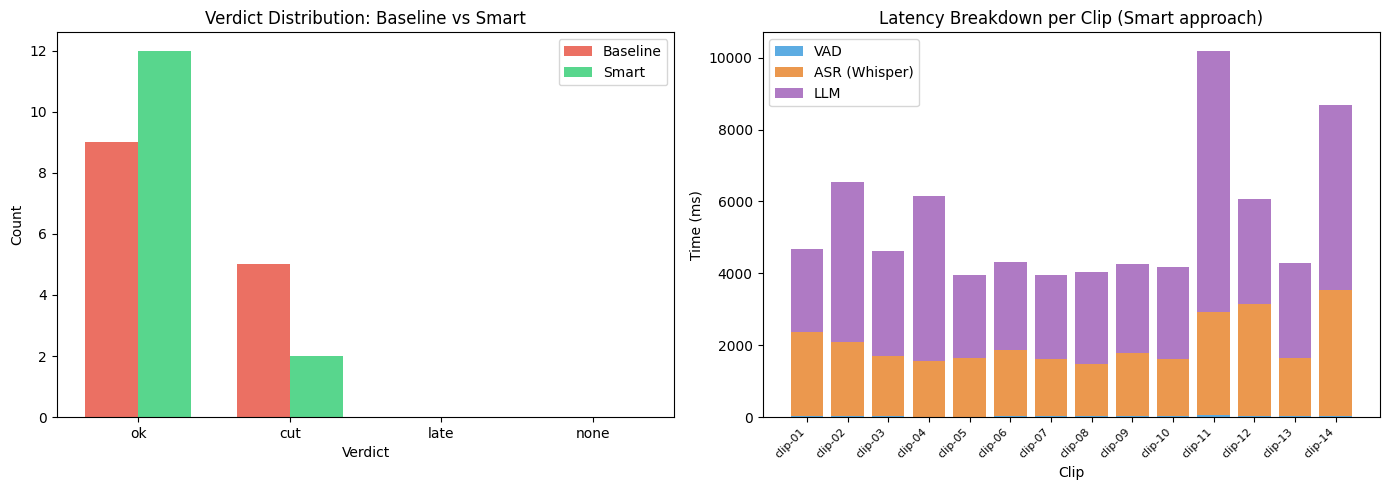

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Verdict distribution
labels_list = ['ok', 'cut', 'late', 'none']
baseline_vals = [b_counts.get(l, 0) for l in labels_list]
smart_vals = [s_counts.get(l, 0) for l in labels_list]

x = np.arange(len(labels_list))
width = 0.35

axes[0].bar(x - width/2, baseline_vals, width, label='Baseline', color='#e74c3c', alpha=0.8)
axes[0].bar(x + width/2, smart_vals, width, label='Smart', color='#2ecc71', alpha=0.8)
axes[0].set_xlabel('Verdict')
axes[0].set_ylabel('Count')
axes[0].set_title('Verdict Distribution: Baseline vs Smart')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_list)
axes[0].legend()

# Chart 2: Latency breakdown (stacked bar)
clips = [r['clip'].replace('.wav','') for r in results]
vad_vals = [r['vad_ms'] for r in results]
asr_vals = [r['asr_ms'] for r in results]
llm_vals = [r['llm_ms'] for r in results]

x2 = np.arange(len(clips))
axes[1].bar(x2, vad_vals, label='VAD', color='#3498db', alpha=0.8)
axes[1].bar(x2, asr_vals, bottom=vad_vals, label='ASR (Whisper)', color='#e67e22', alpha=0.8)
axes[1].bar(x2, llm_vals, bottom=[v+a for v,a in zip(vad_vals, asr_vals)], label='LLM', color='#9b59b6', alpha=0.8)
axes[1].set_xlabel('Clip')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Latency Breakdown per Clip (Smart approach)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(clips, rotation=45, ha='right', fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.show()

## Per-Clip Timeline: Ground Truth vs Baseline vs Smart

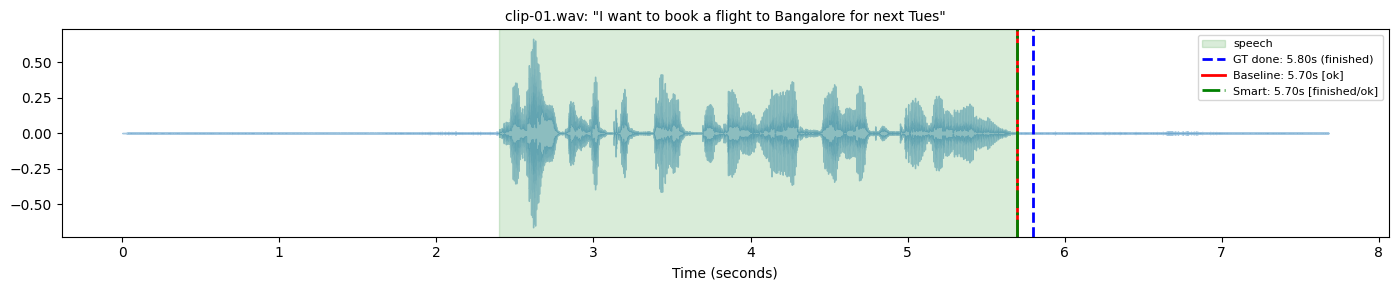

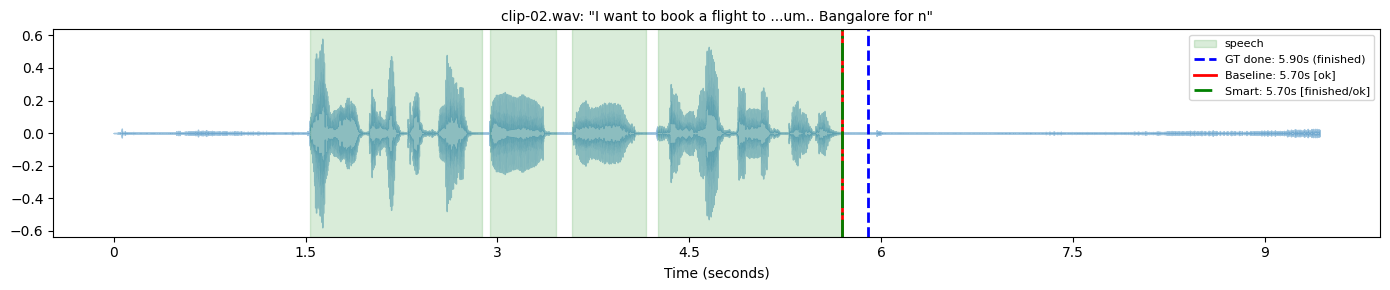

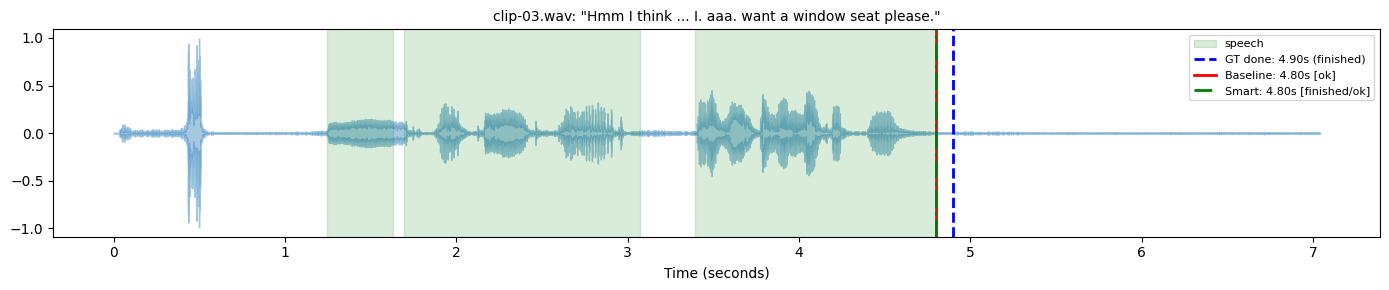

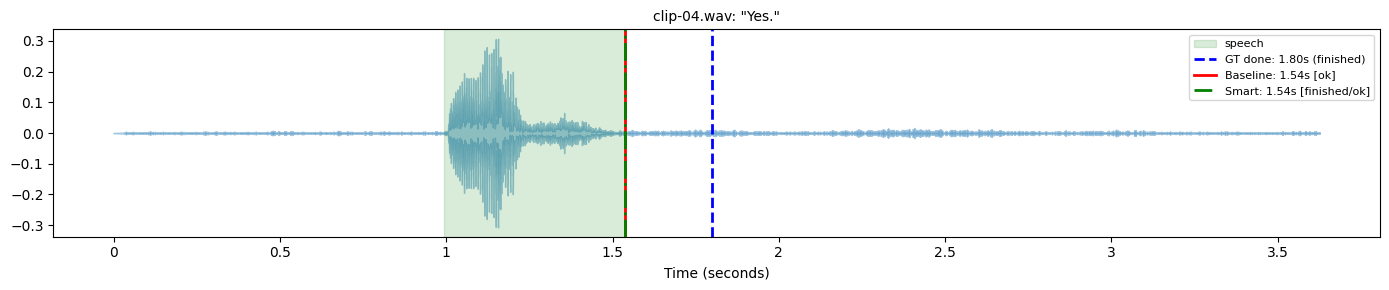

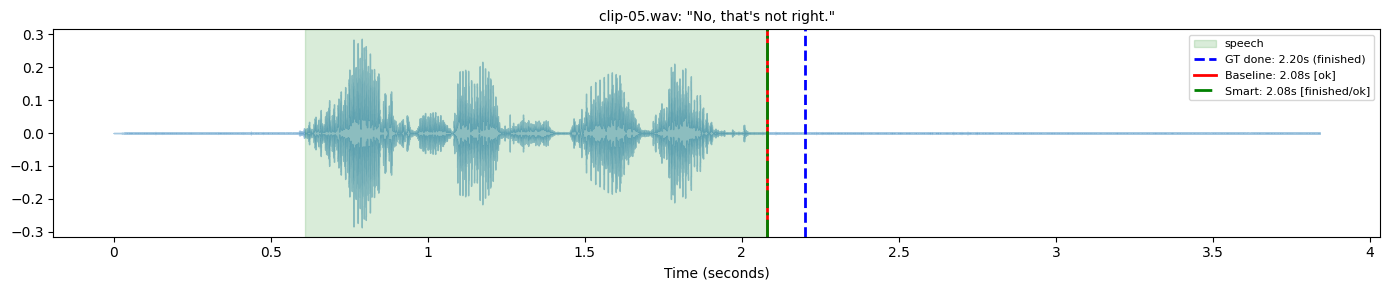

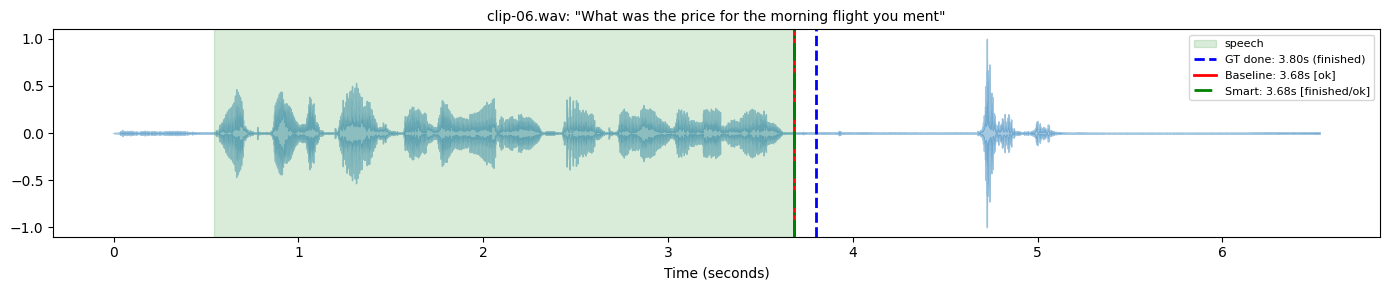

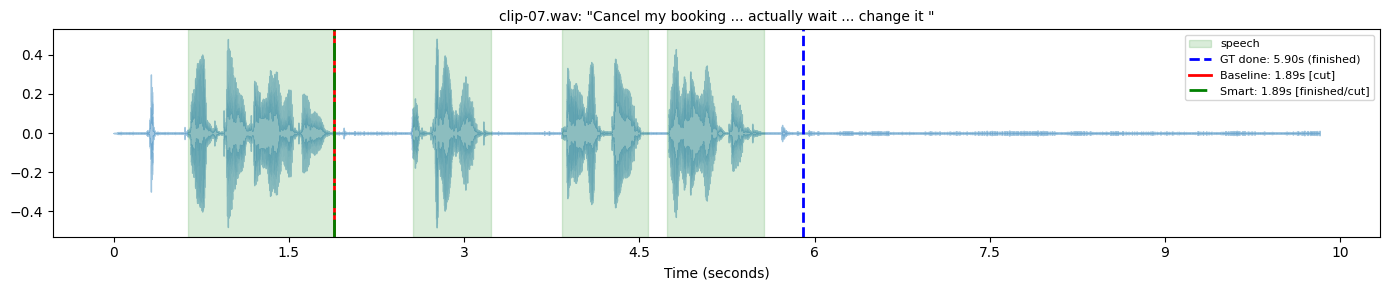

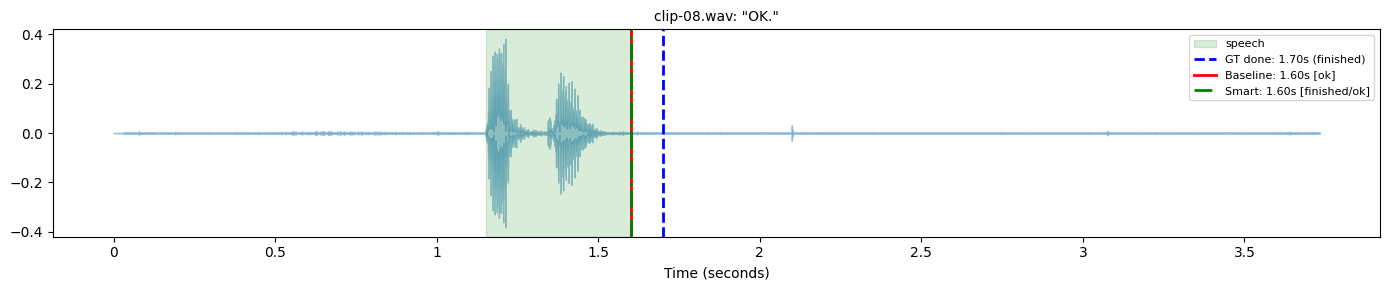

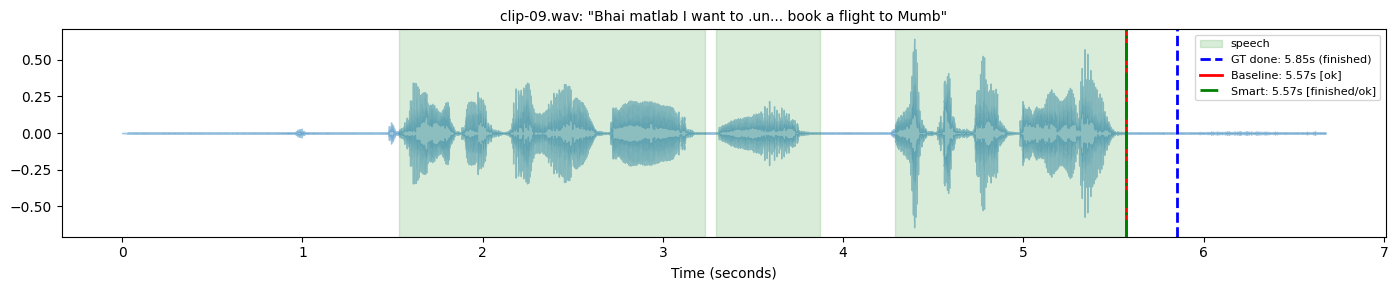

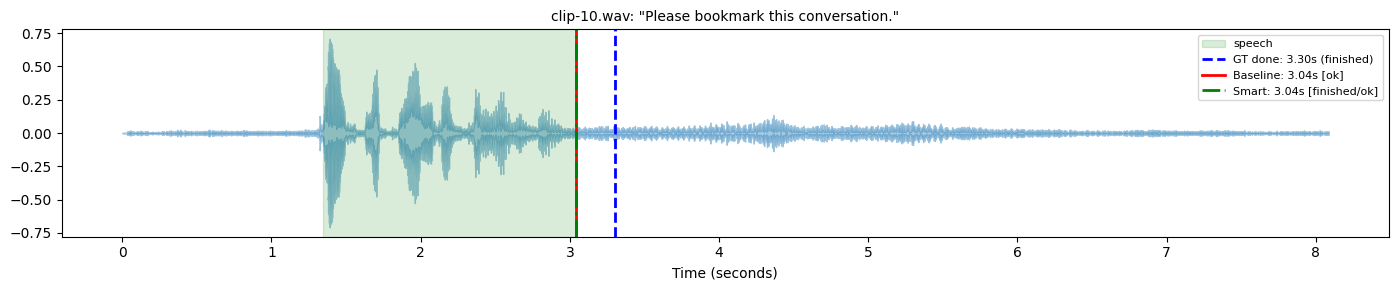

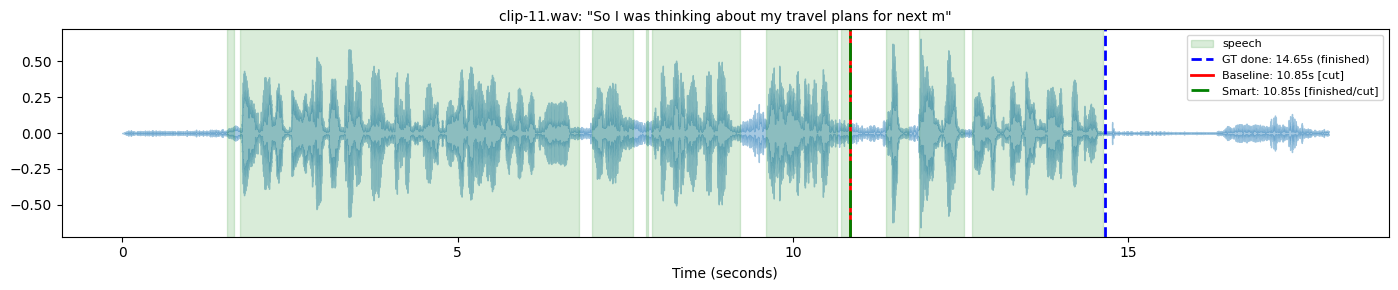

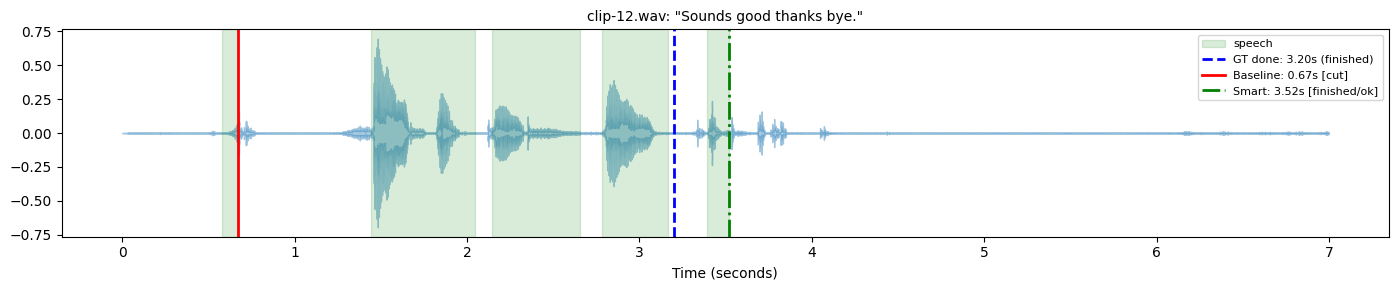

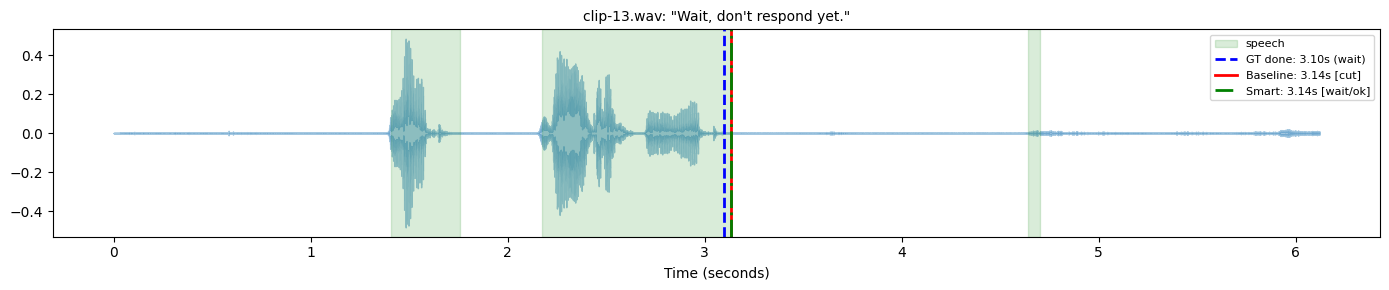

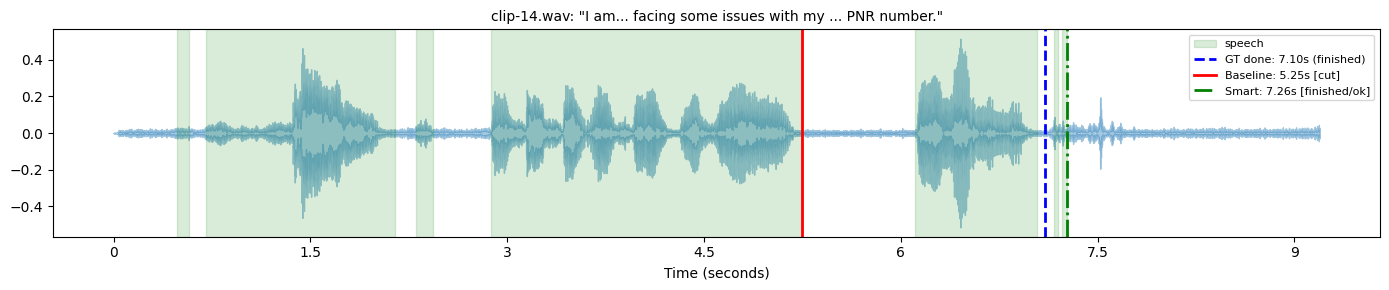

In [17]:
for r in results:
    clip_path = os.path.join(DATA_DIR, r['clip'])
    y_clip, _ = librosa.load(clip_path, sr=SileroVAD.SAMPLE_RATE)
    segs, _ = get_vad_segments(y_clip)

    fig, ax = plt.subplots(figsize=(14, 3))
    librosa.display.waveshow(y_clip, sr=SileroVAD.SAMPLE_RATE, alpha=0.4, ax=ax)

    # Speech segments
    for i, (s, e) in enumerate(segs):
        ax.axvspan(s, e, color='green', alpha=0.15, label='speech' if i == 0 else None)

    # Ground truth
    if r['gt'] is not None:
        ax.axvline(r['gt'], color='blue', linewidth=2, linestyle='--',
                   label=f"GT done: {r['gt']:.2f}s ({r['gt_class']})")

    # Baseline
    if r['baseline_pred'] is not None:
        ax.axvline(r['baseline_pred'], color='red', linewidth=2,
                   label=f"Baseline: {r['baseline_pred']:.2f}s [{r['baseline_verdict']}]")

    # Smart
    if r['smart_pred'] is not None:
        ax.axvline(r['smart_pred'], color='green', linewidth=2, linestyle='-.',
                   label=f"Smart: {r['smart_pred']:.2f}s [{r['smart_class']}/{r['smart_verdict']}]")

    ax.set_title(f"{r['clip']}: \"{r['text']}\"", fontsize=10)
    ax.set_xlabel('Time (seconds)')
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

# Failure Analysis

---

## Section 1: Clips where Baseline fails but Smart works properly

**Clip: `clip-12.wav`** — *"Sounds good thanks bye."*

| | Prediction | Verdict |
|---|---|---|
| Ground Truth | 3.20s (finished) | — |
| Baseline | 0.67s | cut ❌ |
| Smart | 3.52s (finished) | ok ✓ |

**What happened:**
- Baseline cut at the first silence gap ≥500ms, which was a `background Noise` identified as voice my VAD at the very beginning (0.67s).
- The user hadn't even started speaking.

**Why Smart succeeded:**
- At the same gap (0.67s), Whisper transcribed: *""* (Empty transcript)
- The system correctly classified this empty string as `unfinished` because no meaningful speech had occurred.
- Smart continued listening. At the actual end, the full transcript was: *"Sounds good thanks bye."*
- LLM classified as `finished`.

**Key insight:** Silence alone cannot distinguish early disturbance or breaths from turn-ends; semantic understanding is required.

**Clip: `clip-14.wav`** — *"I am... facing some issues with my ... PNR number."*

| | Prediction | Verdict |
|---|---|---|
| Ground Truth | 7.10s (finished) | — |
| Baseline | 5.25s | cut ❌ |
| Smart | 7.26s (finished) | ok ✓ |

**What happened:**
- Baseline cut at the first silence gap ≥500ms, which was a mid-sentence pause after "my..." at 5.25s.
- The silence gap was long enough to trigger the baseline, but the user hadn't finished their thought.

**Why Smart succeeded:**
- At the same gap, Whisper transcribed: *"I am facing some issues with my..."*
- LLM classified this as `unfinished` because the sentence ends with a dangling possessive pronoun ("my...").
- Smart continued listening. At the actual end, the full transcript was: *"I am facing some issues with my PNR number."*
- LLM classified as `finished`.

**Key insight:** LLM reasoning successfully prevents false cuts on grammatically incomplete sentences that contain long pauses.

---

## Section 2: Clips where Smart approach fails

**Clip: `clip-07.wav`** — *"Cancel my booking ... actually wait ... change it "*

| | Prediction | Verdict |
|---|---|---|
| Ground Truth | 5.90s (finished) | — |
| Smart | 1.89s (finished) | cut ❌ |

**Root cause diagnosis — was it ASR or LLM?**

1. **Check the transcript:**
   - Actual text spoken: *"Cancel my booking ... actually wait ... change it "*
   - Whisper transcription at 1.89s: *"Please cancel my booking."*
   - ASR error? **No** — Whisper perfectly transcribed the speech up to the 1.89s mark.

2. **Check the LLM classification:** 
   - Transcript sent to LLM: *"Please cancel my booking."*
   - LLM said: `finished`
   - Was this correct given the transcript? **Yes** — It is a complete thought.

3. **Verdict:**
   - [x] **LLM classification error** — Whisper was correct, and LLM made a reasonable decision based purely on text. However, without acoustic cues (like intake of breath or intonation), the LLM could not know the user intended to add "actually wait...".

**Key insight:** Semantic completion does not always equal acoustic completion; humans often pause after a complete thought before appending to it.

**Clip: `clip-11.wav`** — *"So I was thinking about my travel plans for next month and I really want to visit maybe Bangalore or Hyderabad. I haven't decided yet."*

| | Prediction | Verdict |
|---|---|---|
| Ground Truth | 14.65s (finished) | — |
| Smart | 10.85s (finished) | cut ❌ |

**Root cause diagnosis — was it ASR or LLM?**

1. **Check the transcript:**
   - Actual text spoken: *"So I was thinking about my travel plans for next month and I really want to visit maybe Bangalore or Hyderabad. I haven't decided yet."*
   - Whisper transcription at 10.85s: *"So, I was thinking about my travel plans for next month and I really want to visit maybe Bangalore or Hyderabad. I haven't decided yet."*
   - ASR error? **No**.

2. **Check the LLM classification:** 
   - Transcript sent to LLM: *"So, I was thinking about my travel plans for next month and I really want to visit maybe Bangalore or Hyderabad. I haven't decided yet."*
   - LLM said: `finished`
   - Was this correct given the transcript? **Yes** — The sentence is grammatically complete.

3. **Verdict:**
   - [x] **LLM classification error** — Similar to clip-07, the LLM made a correct semantic judgement on the text it received, but the user simply took a very long pause before continuing their thought.

**Key insight:** Text-only LLM classifiers will occasionally false-cut if the user pauses for >500ms immediately after a grammatically complete sentence.

---

## Section 3: The `wait` class analysis

> [!IMPORTANT]
> This section justifies the 3-class taxonomy (finished/unfinished/wait) over binary (done/not-done).

**Clip: `clip-13.wav`** — *"Wait, don't respond yet."*

- **Baseline behavior:** Baseline treated this as `finished` (silence after complete sentence → predict done). **It would respond to the user — exactly the failure `wait` is designed to prevent.**
- **Smart behavior:** LLM classified as `wait`. Agent can hold on untill the user enters.

**Why binary classification fails here:**
- "Wait, don't respond yet" is grammatically complete → a binary system would say "done"
- Acoustically, the trailing silence looks exactly like a turn-end
- Only semantic understanding of the user's *intent* (they want the agent to hold) distinguishes this from `finished`

**Production implication:** This is why the TEN framework uses the same 3-class taxonomy. A user saying 'hold on' while thinking would get interrupted by a binary system, leading to a frustrating user experience.

---

## Section 4: What would fix these failures in production?

1. **Baseline mid-sentence cuts** → Add semantic tier (= our smart approach). Already solved.
2. **ASR errors propagating** → Use a better ASR model (larger Whisper, or Sarvam for Indian English), or add ASR error correction (Problem 2). Cleaner transcripts → better LLM classification → fewer false-cut errors.
3. **LLM misclassification on complete thoughts** → Incorporate acoustic prosody (pitch, tone) into the endpointing decision, or use multimodal models (like GPT-4o real-time) that process audio directly rather than just text.
4. **Latency** → Replace general-purpose LLM with a fine-tuned small classifier (DistilBERT-level or quantized Qwen2.5-3B). This is the TEN approach. Latency drops from ~3-5s to ~50ms per call.